# Inteligência Computacional - Avaliação 1 : Problema de otimização combinatoria com algoritmo genético.

### Júlia Gabriele e Vitória Emanuele

---
**Tema**:  Otimização de Cobertura em Redes de Sensores Sem Fio (WSN) utilizando Algoritmo Genético.

**Referência**: https://onlinelibrary.wiley.com/doi/full/10.1155/2014/286575

## 1. Definição do problema: 
O nosso problema consiste em uma rede de sensores dispostos em uma grade (grid) 2D, onde precisamos monitorar uma área específica. O desafio é que esses sensores têm bateria limitada. Nós precisamos decidir quais sensores devem ficar ligados e com qual potência de transmissão operar, de forma a **minimizar o gasto de energia**, mas **garantindo que toda a área exigida seja coberta e que a rede não fique desconectada**. Para isso, vamos usar o Algoritmo Genético para encontrar a melhor combinação de ativação desses sensores.

**I. Váriaveis** de projeto: No contexto da nossa grade de sensores, definimos as seguintes variáveis booleanas:

- $y_i$:   **1** se o nó sensor *i* está ativo e **0** caso contrário.
- $x_i$ $_j$:  **1** se o nó *i* cobre o ponto de demanda *j*  e **0** caso contrário.
- $h_i$:   **1** quando o ponto de demanda *j* não está coberto (ponto cego).

**II. Função Objetivo** ($f(x)$): A função objetivo que o nosso Algoritmo Genético buscará **minimizar é o Custo Total** (*FF - Fitness Function*), que é a soma do Custo de Uso de Energia (*UsageCost*) com o Custo de Penalidade (*PenaltyCost*):

$FF = min(UsageCost + PenaltyCost)$

Onde :

$ UsageCost = ∑( AE_i + PC_i + EC) × y_i$: Soma da energia gasta para ligar o nó $AE_i$, penalidade de distância $PC_i$ e consumo do modo de operação EC.

$ PenaltyCost= ∑∑(NC_j$ $_k$ $+ OPCE_j$ $_k$ $)× h_k$ : Penalidade NC aplicada quando uma área *k* fica sem cobertura, mais erros de sobreposição OPCE.

**III. Restrições** (Desigualdade $g(x) ≤ 0$ e Igualdade $h(x) = 0$):

- $x_i$ $_j$ $≤$ $y_i$: Um nó *i* só pode cobrir um ponto *j* se o nó *i* estiver ativo ($y_i = 1$).
- $∑( x_i$ $_j$ $ + h_j ) ≥ 1$: Todo ponto de demanda *j* deve estar coberto por pelo menos um sensor ou ser registrado como um ponto cego ($h_j = 1 $).


## 2. Definição dos elementos do Algoritmo Genético:
Com base na modelagem da rede de sensores dispostos em uma grade $L×L$, o Algoritmo Genético (AG) é estruturado da seguinte maneira:

I. Cromossomo, genes e alelos **(Encode/Decode)**:

- **Cromossomo**: uma solução intera é representada por uma string de bits (cadeira binária). O comprimeto total do cromossomo é de $2L^2$.
- **Genes**: Cada par de bits representa um nó sensor individual na grade.
- **Alelos**: Os valores que um gene pode assumir são 4, codificados em 2 bits, indicando o modo de operações do sensor:
    - 00: inativa (sensor desligado);
    - 01: modo A ativo (Alcance longo, gasta 4x mais energia);
    - 10: Modo B ativo (Alcance médio, gasta 2x mais energia);
    - 11: Modo C ativo (Alcance curto, gasta 1x energia).
- **Encode/Decode**: A função de encode lê a grade de sensores atual e a transforma em uma string de bits sequencial. O decode pega a string de bits do cromossomo e a converte de volta em uma grade espacial com modos de operação e áreas de cobertura associadas.

II. **Função de Aptidão (Fitness)**: Como definido no item 1, avalia o cromossomo calculando o menor custo possível. Quanto menor a energia utilizada e menos pontos cegos gerados ($FF = UsageCost + PenaltyCost$), maior a aptidão do cromossomo para sobreviver.

III. **Seleção**: Utilizaremos o método da Roleta (Roulette-Wheel), onde os cromossomos recebem uma probabilidade de seleção proporcional à sua aptidão, priorizando os indivíduos mais aptos.


IV. **Cruzamento**: Utilizaremos o cruzamento de Ponto Único (Single point crossover). Os bits de dois cromossomos pais são divididos em um ponto aleatório e recombinados para formar dois filhos.

V. **Mutação**: Alteração aleatória de um gene (par de bits) para outro modo de operação, ajudando a explorar novos cenários e evitando ótimos locais.

VI. **Condição de parada**: O algoritmo convergirá através de um limite máximo de iterações (gerações), como 100 gerações, ou quando os custos estabilizarem sem melhoras.


## 3. Dados do Problema:

Para simular o problema de Cobertura da Rede (*Network Coverage*) detalhado no artigo base, adotaremos um ambiente em formato de grade espacial (grid) $L \times L$. Os parâmetros da simulação e do algoritmo genético seguirão os cenários propostos pelos autores:

*   **Ambiente Espacial:** Uma área monitorada de $100\text{m} \times 100\text{m}$ [2, 3].
*   **Grade de Sensores:** Para a modelagem da grade $L \times L$, adotaremos $L = 10$, totalizando $100$ nós sensores ($L^2$) distribuídos uniformemente.
*   **Modos de Operação e Custo de Energia (EC):** Os autores definem o custo de operação proporcional ao alcance de transmissão. O Modo A consome 4 vezes mais que o C, e o Modo B consome 2 vezes mais que o C.
    *   Inativo (`00`): Custo 0
    *   Modo A (`01` - Maior alcance): Custo 4
    *   Modo B (`10` - Médio alcance): Custo 2
    *   Modo C (`11` - Menor alcance): Custo 1
*   **Parâmetros do Algoritmo Genético:** Utilizaremos a configuração padrão apontada no estudo:
    *   **Tamanho da população (`popsize`):** 100 indivíduos.
    *   **Número de gerações (`ngen`):** 100 iterações.
    *   **Taxa de cruzamento (`pcross`):** 0.5 (50%).
    *   **Taxa de mutação (`pmut`):** 0.2 (20%).
    *   **Comprimento do cromossomo:** $2 \times L^2 = 200$ bits (já que cada um dos 100 sensores exige 2 bits).



In [2]:
import random
import numpy as np
import matplotlib.pyplot as plt


# parametros do ambiente e rede
AREA_SIZE = 100           
L = 10                    
NUM_SENSORS = L ** 2

# custos de energia (EC) dos alelos. Dicionario mapeando os bits para o respectivo custo de energia
ENERGY_COST = {
    '00': 0, # Desligado
    '01': 4, # modo A (longo alcance)
    '10': 2, # modo B (medio alcance)
    '11': 1  # modo C (curto alcance)
}

# raio de Cobertura (valores hipoteticos em metros para testar a aptidao)
COVERAGE_RADIUS = {
    '00': 0,
    '01': 30, # modo A cobre mais area
    '10': 20, # modo B cobre area media
    '11': 10  # modo C cobre area pequena
}

# parametros do algoritmo genetico
POP_SIZE = 100            # tamanho da populacao
NUM_GENERATIONS = 100     # condicao de parada (iteracoes)
CROSSOVER_RATE = 0.5      # taxa de cruzamento (50%)
MUTATION_RATE = 0.2       # taxa de mutacao (20%)
CHROMOSOME_LENGTH = NUM_SENSORS * 2 # comprimento: 200 bits

print(f"--- Inicialização: ---")
print(f"Total de Sensores: {NUM_SENSORS}")
print(f"Tamanho do Cromossomo: {CHROMOSOME_LENGTH} bits")
print(f"Tamanho da População: {POP_SIZE} indivíduos")

--- Inicialização: ---
Total de Sensores: 100
Tamanho do Cromossomo: 200 bits
Tamanho da População: 100 indivíduos


## 4. ImplementaçÕ

In [9]:
# criacao da populacao inicial

def create_individual(length):
    # gera um cromossomo aleatorio de '0's e '1's)
    return ''.join(random.choice(['0', '1']) for _ in range(length))

def create_population(pop_size, length):
    return [create_individual(length) for _ in range(pop_size)]

# decodificacao (decode)
def decode_chromosome(chromosome):
    genes = [chromosome[i:i+2] for i in range(0, len(chromosome), 2)]
    return genes

# cruzamento (single point crossover)
def crossover(parent1, parent2, rate):
    if random.random() < rate:
        point = random.randint(1, len(parent1) - 1)

        child1 = parent1[:point] + parent2[point:]
        child2 = parent2[:point] + parent1[point:]
        return child1, child2
    return parent1, parent2

#mutacao (bit-flip mutation)
def mutate(chromosome, rate):
    mutated = ""
    for bit in chromosome:
        if random.random() < rate:
            mutated += '1' if bit == '0' else '0'
        else:
            mutated += bit
    return mutated

In [10]:
# selecao (roleta / Roulette-Wheel)
def roulette_wheel_selection(population, fitness_scores):
    # nosso problema eh de minimizacao de custo (energia + pontos cegos). A Roleta padrao favorece valores maiores. Entao precisamos inverter as notas (scores).
    max_fitness = max(fitness_scores)
    
    # inverte os scores para que os menores custos ganhem a maior "fatia" da roleta
    inverted_scores = [max_fitness - score + 1 for score in fitness_scores]
    total_score = sum(inverted_scores)
    
    pick = random.uniform(0, total_score)
    current = 0
    for i, individual in enumerate(population):
        current += inverted_scores[i]
        if current >= pick:
            return individual
    return population[-1]

print("Operadores geneticos definidos com sucesso.")


Operadores geneticos definidos com sucesso.


Como a roleta sorteia fatias maiores para números maiores, e o objetivo do artigo é minimizar o uso de energia, nós implementamos uma lógica de inversão (max_fitness - score + 1) para garantir que os menores custos tenham a maior chance de serem sorteados.

A função de aptidão avalia a qualidade da solução. Nosso objetivo é **minimizar** o valor dessa função. De acordo com o modelo matemático, o custo total (FF) é dado por:
`FF = UsageCost + PenaltyCost`

1. **UsageCost:** É a soma da energia consumida pelos sensores que estão ativos. O Modo A custa 4, o B custa 2, e o C custa 1.
2. **PenaltyCost (Penalidade de Cobertura):** Simulamos as posições físicas $(x, y)$ dos nós em uma grade. Se um ponto de demanda ficar fora do raio de cobertura de todos os sensores ativos, aplicamos uma penalidade alta (ex: 50 pontos de custo) para "punir" o cromossomo por deixar pontos cegos na rede.


In [11]:
def calculate_fitness(chromosome):
    genes = decode_chromosome(chromosome)
    usage_cost = 0
    
    # mapeamento fisico dos sensores ativos (x, y, raio)
    active_sensors = []
    for i, gene in enumerate(genes):
        usage_cost += ENERGY_COST[gene] # soma o gasto de energia (UsageCost)
        
        if gene != '00':
            # transforma o indice 1D (0 a 99) em coordenadas 2D na grade 10x10
            x = (i % L) * (AREA_SIZE / L) 
            y = (i // L) * (AREA_SIZE / L)
            active_sensors.append((x, y, COVERAGE_RADIUS[gene]))
            
    # verificacao de cobertura (PenaltyCost)
    penalty_cost = 0
    # verificamos 100 pontos centrais de demanda distribuidos pelo ambiente
    for i in range(NUM_SENSORS):
        target_x = (i % L) * (AREA_SIZE / L)
        target_y = (i // L) * (AREA_SIZE / L)
        is_covered = False
        
        # verifica se este ponto eh coberto por algum sensor ativo
        for sx, sy, radius in active_sensors:
            # distancia euclidiana entre o ponto de demanda e o sensor
            distance = ((target_x - sx)**2 + (target_y - sy)**2)**0.5
            if distance <= radius:
                is_covered = True
                break
                
        # aplica penalidade severa (NC) para cada ponto cego, conforme modelagem matematica
        if not is_covered:
            penalty_cost += 50 
            
    # funcao objetivo: minimizar (Energia + Penalidades)
    return usage_cost + penalty_cost


In [12]:
# execucao do algoritmo genetico

def run_genetic_algorithm():
    # cria a populacao inicial (geracao 0)
    population = create_population(POP_SIZE, CHROMOSOME_LENGTH)
    best_fitness_history = []
    
    for generation in range(NUM_GENERATIONS):
        # avalia o custo de todos os cromossomos na geracao
        fitness_scores = [calculate_fitness(ind) for ind in population]
        
        # encontra o individuo de menor custo (melhor aptidao)
        best_generation_fitness = min(fitness_scores)
        best_fitness_history.append(best_generation_fitness)
        
        new_population = []
        
        # salva o melhor individuo para nao ser perdido
        best_index = fitness_scores.index(best_generation_fitness)
        new_population.append(population[best_index])
        
        # gera o restante da populacao
        while len(new_population) < POP_SIZE:
            # selecao
            parent1 = roulette_wheel_selection(population, fitness_scores)
            parent2 = roulette_wheel_selection(population, fitness_scores)
            
            # cruzamento e mutacao
            child1, child2 = crossover(parent1, parent2, CROSSOVER_RATE)
            child1 = mutate(child1, MUTATION_RATE)
            child2 = mutate(child2, MUTATION_RATE)
            
            new_population.extend([child1, child2])
            
        # atualiza a populacao, garantindo nao exceder POP_SIZE devido ao elitismo
        population = new_population[:POP_SIZE]
        
        # Log a cada 10 geracoes
        if generation % 10 == 0:
            print(f"Geração {generation:03d} | Melhor Custo Atual: {best_generation_fitness}")
            
    # retorna o melhor cromossomo absoluto e o historico
    final_fitness_scores = [calculate_fitness(ind) for ind in population]
    best_overall_index = final_fitness_scores.index(min(final_fitness_scores))
    return population[best_overall_index], best_fitness_history

Iniciando a evolução do Algoritmo Genético...

Geração 000 | Melhor Custo Atual: 134
Geração 010 | Melhor Custo Atual: 124
Geração 020 | Melhor Custo Atual: 118
Geração 030 | Melhor Custo Atual: 108
Geração 040 | Melhor Custo Atual: 108
Geração 050 | Melhor Custo Atual: 108
Geração 060 | Melhor Custo Atual: 108
Geração 070 | Melhor Custo Atual: 108
Geração 080 | Melhor Custo Atual: 108
Geração 090 | Melhor Custo Atual: 108

--- EVOLUÇÃO CONCLUÍDA ---
Custo Final Otimizado: 107


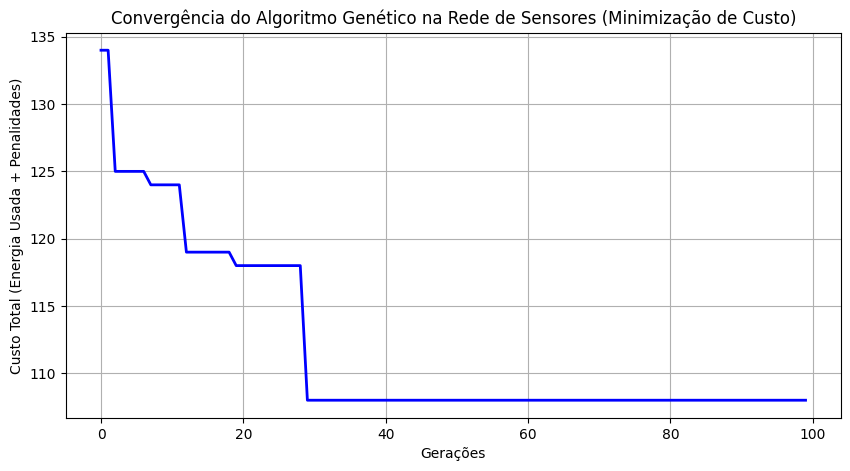

In [13]:
print("Iniciando a evolução do Algoritmo Genético...\n")
best_chromosome, history = run_genetic_algorithm()

print(f"\n--- EVOLUÇÃO CONCLUÍDA ---")
print(f"Custo Final Otimizado: {calculate_fitness(best_chromosome)}")

plt.figure(figsize=(10, 5))
plt.plot(history, color='blue', linewidth=2)
plt.title("Convergência do Algoritmo Genético na Rede de Sensores (Minimização de Custo)")
plt.xlabel("Gerações")
plt.ylabel("Custo Total (Energia Usada + Penalidades)")
plt.grid(True)
plt.show()


## 5. Ajuste de Parâmetros:

In [14]:
# Grid search para ajuste de parametros 

# modificando levemente a funcao para aceitar os parametros do grid como argumentos
def run_ga_grid(pop_size, n_gen, cross_rate, mut_rate):
    population = create_population(pop_size, CHROMOSOME_LENGTH)
    for generation in range(n_gen):
        fitness_scores = [calculate_fitness(ind) for ind in population]
        best_generation_fitness = min(fitness_scores)
        
        # elitismo
        new_population = [population[fitness_scores.index(best_generation_fitness)]] 
        
        while len(new_population) < pop_size:
            parent1 = roulette_wheel_selection(population, fitness_scores)
            parent2 = roulette_wheel_selection(population, fitness_scores)
            
            child1, child2 = crossover(parent1, parent2, cross_rate)
            child1 = mutate(child1, mut_rate)
            child2 = mutate(child2, mut_rate)
            
            new_population.extend([child1, child2])
            
        population = new_population[:pop_size]
        
    final_scores = [calculate_fitness(ind) for ind in population]
    return min(final_scores)

# Definindo o Grid de valores para testar. Misturamos os valores do artigo com valores maiores e menores para comparacao
grid_pop_size = [4]        # artigo usou 100
grid_cross_rate = [0.5, 0.8]     # artigo usou 0.5
grid_mut_rate = [0.1, 0.2, 0.5]  # artigo usou 0.2
n_generations = 50               # Reduzido para 50 para o teste rodar mais rapido

melhor_custo_grid = float('inf')
melhor_combinacao = None

In [21]:
# executando o Grid Search (testando todas as combinacoes)
for p_size in grid_pop_size:
    for c_rate in grid_cross_rate:
        for m_rate in grid_mut_rate:
            custo_obtido = run_ga_grid(p_size, n_generations, c_rate, m_rate)
            print(f"Testado: População={p_size:3d} | Cruzamento={c_rate:.1f} | Mutação={m_rate:.1f} => Custo Final: {custo_obtido}")
            
            # salva a melhor configuracao encontrada
            if custo_obtido < melhor_custo_grid:
                melhor_custo_grid = custo_obtido
                melhor_combinacao = (p_size, c_rate, m_rate)


print(f"Melhor configuracao encontrada: ")
print(f"Tamanho da Populacao (popsize): {melhor_combinacao}")
print(f"Taxa de Cruzamento (pcross): {melhor_combinacao}")
print(f"Taxa de Mutacao (pmut): {melhor_combinacao}")
print(f"Menor Custo Final Obtido: {melhor_custo_grid}")

Testado: População=  4 | Cruzamento=0.5 | Mutação=0.1 => Custo Final: 107
Testado: População=  4 | Cruzamento=0.5 | Mutação=0.2 => Custo Final: 122
Testado: População=  4 | Cruzamento=0.5 | Mutação=0.5 => Custo Final: 132
Testado: População=  4 | Cruzamento=0.8 | Mutação=0.1 => Custo Final: 115
Testado: População=  4 | Cruzamento=0.8 | Mutação=0.2 => Custo Final: 123
Testado: População=  4 | Cruzamento=0.8 | Mutação=0.5 => Custo Final: 136
Melhor configuracao encontrada: 
Tamanho da Populacao (popsize): (4, 0.5, 0.1)
Taxa de Cruzamento (pcross): (4, 0.5, 0.1)
Taxa de Mutacao (pmut): (4, 0.5, 0.1)
Menor Custo Final Obtido: 107
